<a href="https://colab.research.google.com/github/AleR26/ColabFiles/blob/main/tuitsCambioClimatico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos
##Procesamiento de Lenguaje Natural


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/NLP/tuits_cambio_climatico.csv')
display(df)

,tuit
0,Excelente iniciativa de el uso de energías ren...
1,Inspirador que la contaminación plástica afect...
2,Datos muestran que los niveles de CO2 disminuy...
3,Indignante que las temperaturas globales sigan...
4,Inspirador que la deforestación continúe 🌊 #So...
...,...
495,Según estudios las temperaturas globales sigan...
496,Es alentador ver que se implementen políticas ...
497,Se informa que las emisiones de gases efecto i...
498,Inaceptable que la contaminación plástica afec...


Conversión a minúsculas

In [4]:
df['tuit'] = df['tuit'].str.lower()
display(df.head())

,tuit
0,excelente iniciativa de el uso de energías ren...
1,inspirador que la contaminación plástica afect...
2,datos muestran que los niveles de co2 disminuy...
3,indignante que las temperaturas globales sigan...
4,inspirador que la deforestación continúe 🌊 #so...


Eliminación de puntuaciones

In [8]:
import regex as re
df['tuit'] = df['tuit'].str.replace(r'[^A-z\s]', '', regex=True)
display(df.head())

,tuit
0,excelente iniciativa de el uso de energas reno...
1,inspirador que la contaminacin plstica afecte ...
2,datos muestran que los niveles de co disminuya...
3,indignante que las temperaturas globales sigan...
4,inspirador que la deforestacin contine sosten...


Tokenización con spaCy

In [14]:
import re
import spacy
import nltk
import unicodedata
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [ ]:
!python -m spacy download es_core_news_sm

In [18]:
nltk.download('stopwords')
nlp = spacy.load('es_core_news_sm')
docs = nlp.pipe(df['tuit'])
tokens = [token.text for doc in docs for token in doc]
print(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['excelente', 'iniciativa', 'de', 'el', 'uso', 'de', 'energas', 'renovables', 'se', 'expanda', ' ', 'medioambiente', 'inspirador', 'que', 'la', 'contaminacin', 'plstica', 'afecte', 'los', 'ocanos', ' ', 'sostenibilidad', 'datos', 'muestran', 'que', 'los', 'niveles', 'de', 'co', 'disminuyan', ' ', 'medioambiente', 'indignante', 'que', 'las', 'temperaturas', 'globales', 'sigan', 'aumentando', ' ', 'ecoconciencia', 'inspirador', 'que', 'la', 'deforestacin', 'contine', ' ', 'sostenibilidad', 'investigacin', 'revela', 'que', 'la', 'deforestacin', 'contine', ' ', 'planeta', 'me', 'alegra', 'que', 'las', 'temperaturas', 'globales', 'sigan', 'aumentando', ' ', 'ecoconciencia', 'inaceptable', 'que', 'las', 'temperaturas', 'globales', 'sigan', 'aumentando', ' ', 'cambioclimtico', 'datos', 'muestran', 'que', 'los', 'niveles', 'de', 'co', 'disminuyan', ' ', 'salvemoselplaneta', 'estadsticas', 'indican', 'que', 'la', 'deforestacin', 'contine', ' ', 'salvemoselplaneta', 'estadsticas', 'indican', 'qu

Eliminación de Stopwords

In [20]:
stop_words  = set(stopwords.words('spanish'))
tokens_clean = [word for word in tokens if word not in stop_words]
print(tokens_clean)

['excelente', 'iniciativa', 'uso', 'energas', 'renovables', 'expanda', ' ', 'medioambiente', 'inspirador', 'contaminacin', 'plstica', 'afecte', 'ocanos', ' ', 'sostenibilidad', 'datos', 'muestran', 'niveles', 'co', 'disminuyan', ' ', 'medioambiente', 'indignante', 'temperaturas', 'globales', 'sigan', 'aumentando', ' ', 'ecoconciencia', 'inspirador', 'deforestacin', 'contine', ' ', 'sostenibilidad', 'investigacin', 'revela', 'deforestacin', 'contine', ' ', 'planeta', 'alegra', 'temperaturas', 'globales', 'sigan', 'aumentando', ' ', 'ecoconciencia', 'inaceptable', 'temperaturas', 'globales', 'sigan', 'aumentando', ' ', 'cambioclimtico', 'datos', 'muestran', 'niveles', 'co', 'disminuyan', ' ', 'salvemoselplaneta', 'estadsticas', 'indican', 'deforestacin', 'contine', ' ', 'salvemoselplaneta', 'estadsticas', 'indican', 'conciencia', 'ambiental', 'crezca', ' ', 'sostenibilidad', 'datos', 'muestran', 'implementen', 'polticas', 'verdes', ' ', 'planeta', 'estadsticas', 'indican', 'uso', 'energa

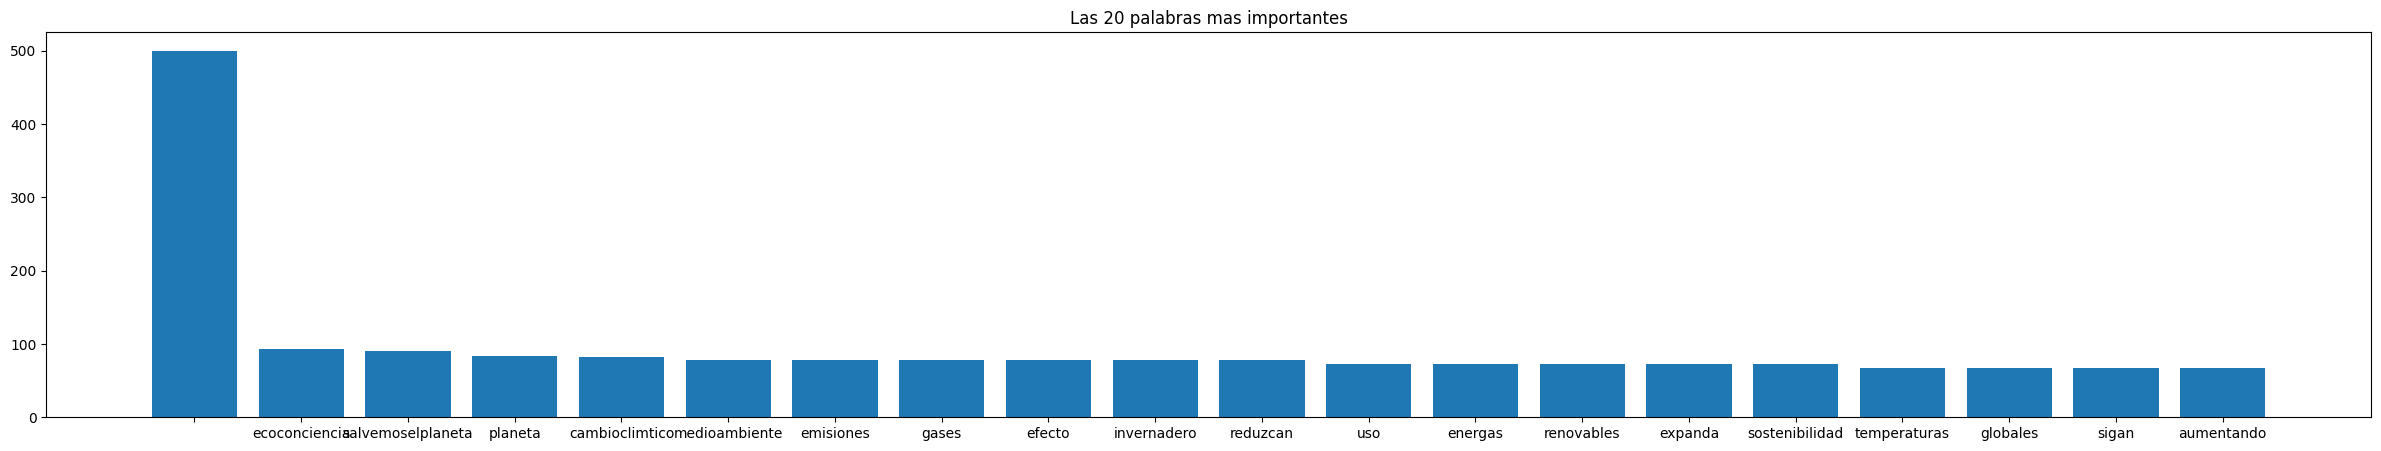

In [24]:
counter = Counter(tokens_clean)
most_common = counter.most_common(20)
palabras, freqs = zip(*most_common)
plt.figure(figsize=(30,5))
plt.bar(palabras,freqs)
plt.title('Las 20 palabras mas importantes')
plt.show()

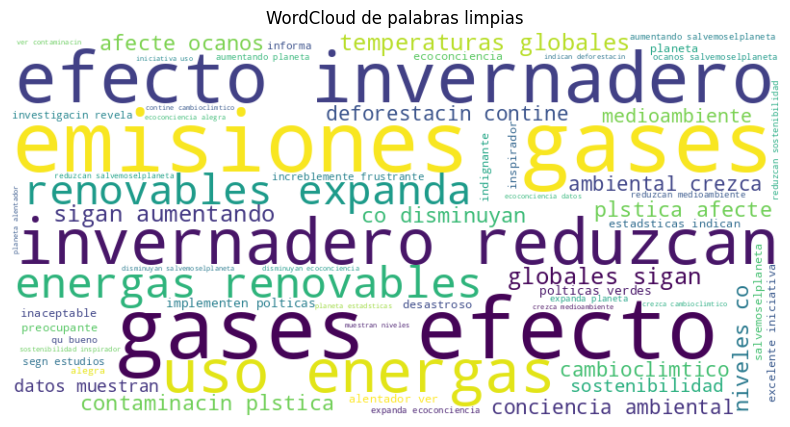

In [26]:
# WordCloud de palabras limpias
text_joined = ' '.join(tokens_clean)
wc = WordCloud(width=800, height=400, background_color="white").generate(text_joined)
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud de palabras limpias")
plt.show()